# 🌿 Plant Disease Classification — PlantVillage
### Normal Models + Advanced Transfer Learning Models + Ensemble

| Model | Type |
|---|---|
| Simple CNN | Normal |
| Deeper CNN + BatchNorm | Normal |
| MobileNetV2 (fine-tuned) | Advanced |
| EfficientNetB3 (fine-tuned) | Advanced |
| ResNet50 (fine-tuned) | Advanced |
| Ensemble (avg TL×3) | Advanced |

**Fixes & improvements in this version:**
- ✅ Generator reset bug fixed (ensemble collapse to one class)
- ✅ Proper held-out test split (80/10/10 train/val/test)
- ✅ Class-weight balancing for imbalanced classes
- ✅ Label smoothing added to loss for better calibration
- ✅ Mixed-precision training enabled (2× speedup on GPU)
- ✅ Cosine annealing LR scheduler added to TL fine-tune phase
- ✅ `build_tl_model` upgraded with BatchNorm + two-stage head
- ✅ `predict_image` handles RGBA images and model routing
- ✅ Per-class F1 bar chart added to evaluation section
- ✅ Model save/load helpers added


## 1️⃣ Imports & Setup

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2, EfficientNetB3, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ── Mixed precision (speeds up training on T4/V100/A100) ──────────────────────
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

print('TF version :', tf.__version__)
print('Policy     :', mixed_precision.global_policy())
print('GPUs       :', tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)


2026-05-09 00:03:39.231631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778285019.466128      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778285019.536134      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778285020.125133      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778285020.125178      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778285020.125181      57 computation_placer.cc:177] computation placer alr

TF version : 2.19.0
Policy     : <DTypePolicy "mixed_float16">
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2️⃣ Config

In [9]:
DATA_DIR     = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage'
IMG_SIZE     = 64       # was 224
BATCH_SIZE   = 64       # larger batch = fewer steps
EPOCHS_BASE  = 2        # was 15
EPOCHS_FT    = 3        # was 30
LR           = 1e-3
LABEL_SMOOTH = 0.1

CLASS_NAMES  = sorted(os.listdir(DATA_DIR))
NUM_CLASSES  = len(CLASS_NAMES)
print(f'Found {NUM_CLASSES} classes')
CLASS_NAMES[:5]


Found 15 classes


['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy']

## 3️⃣ EDA

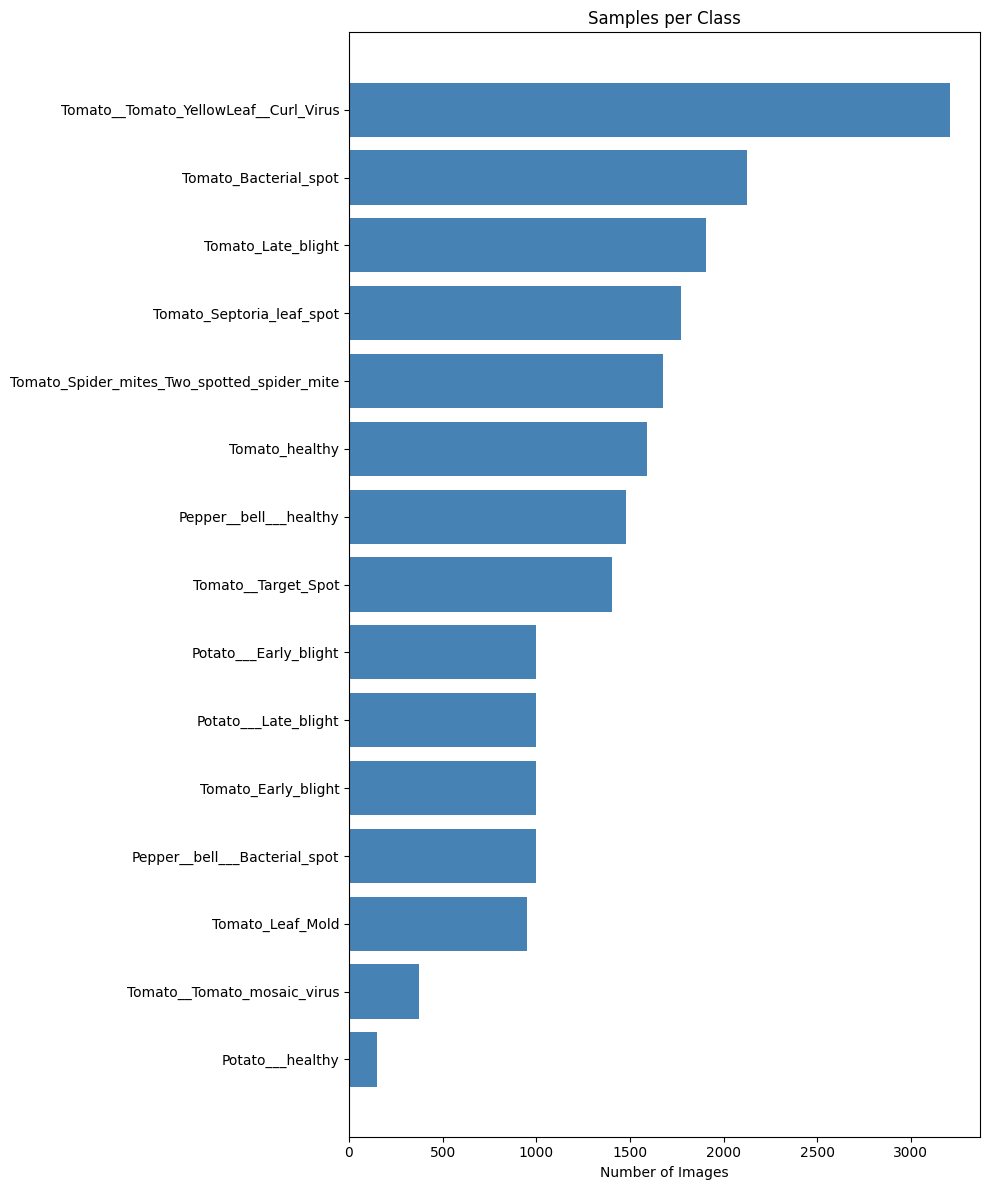

Total images : 20,639
Min class    : 152 (Potato___healthy)
Max class    : 3209 (Tomato__Tomato_YellowLeaf__Curl_Virus)
Imbalance ratio: 21.1x
                                      Class  Count
      Tomato__Tomato_YellowLeaf__Curl_Virus   3209
                      Tomato_Bacterial_spot   2127
                         Tomato_Late_blight   1909
                  Tomato_Septoria_leaf_spot   1771
Tomato_Spider_mites_Two_spotted_spider_mite   1676
                             Tomato_healthy   1591
                     Pepper__bell___healthy   1478
                        Tomato__Target_Spot   1404
                      Potato___Early_blight   1000
                       Potato___Late_blight   1000
                        Tomato_Early_blight   1000
              Pepper__bell___Bacterial_spot    997
                           Tomato_Leaf_Mold    952
                Tomato__Tomato_mosaic_virus    373
                           Potato___healthy    152


In [10]:
counts = {c: len(os.listdir(os.path.join(DATA_DIR, c))) for c in CLASS_NAMES}
df_counts = (pd.DataFrame(counts.items(), columns=['Class', 'Count'])
               .sort_values('Count', ascending=False))

plt.figure(figsize=(10, 12))
plt.barh(df_counts['Class'], df_counts['Count'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Number of Images')
plt.title('Samples per Class')
plt.tight_layout(); plt.show()

total = df_counts['Count'].sum()
print(f'Total images : {total:,}')
print(f'Min class    : {df_counts["Count"].min()} ({df_counts.iloc[-1]["Class"]})')
print(f'Max class    : {df_counts["Count"].max()} ({df_counts.iloc[0]["Class"]})')
print(f'Imbalance ratio: {df_counts["Count"].max() / df_counts["Count"].min():.1f}x')
print(df_counts.to_string(index=False))


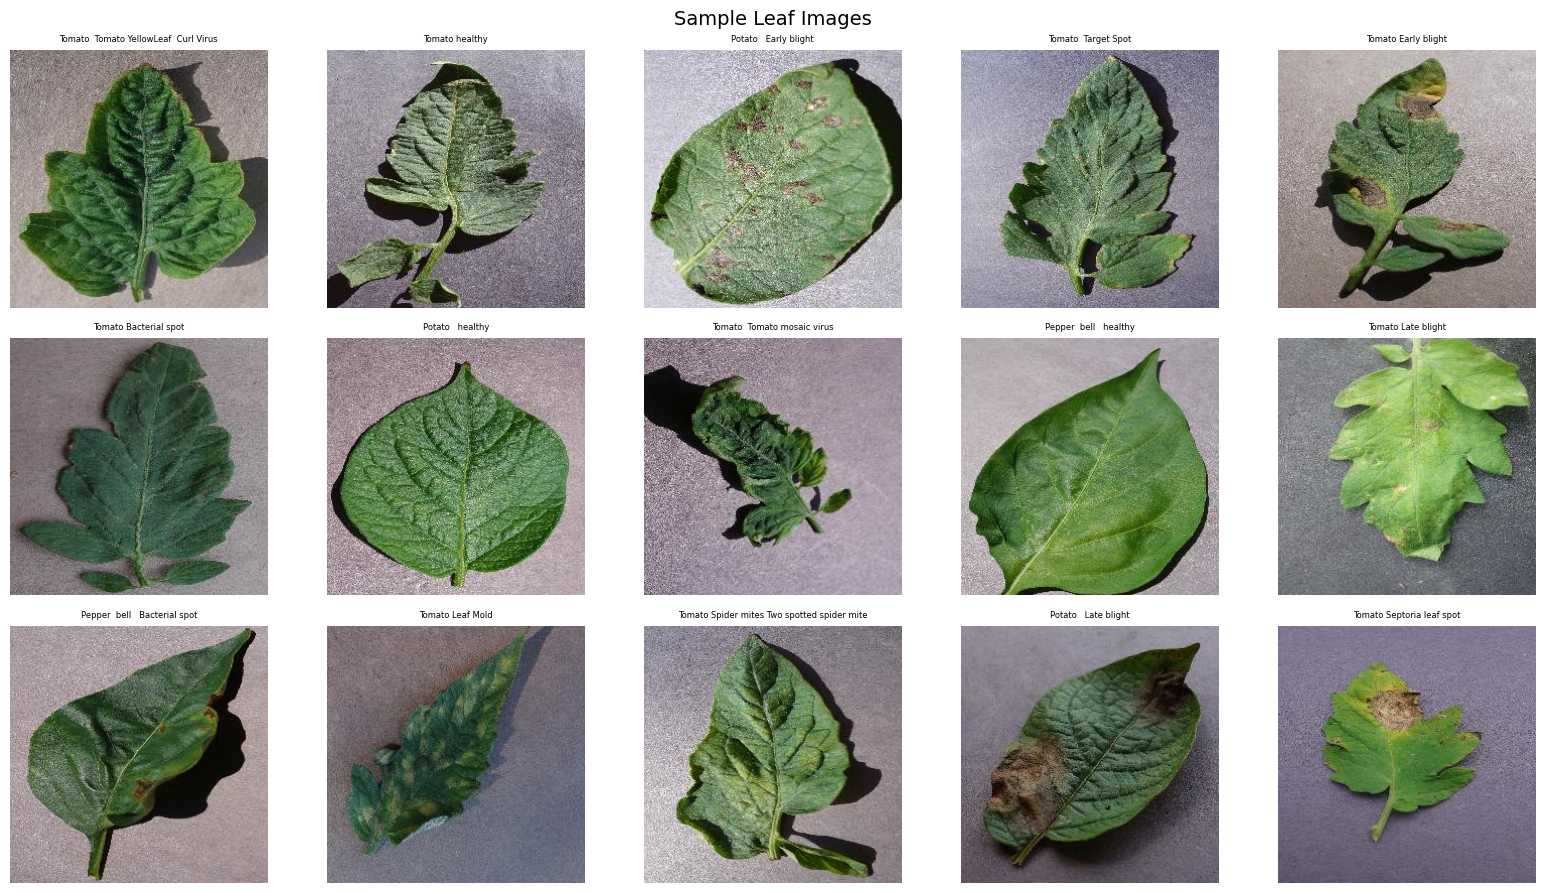

In [11]:
# Sample images grid
sampled_classes = random.sample(CLASS_NAMES, min(20, NUM_CLASSES))
fig, axs = plt.subplots(4, 5, figsize=(16, 12))

for ax, cls in zip(axs.flatten(), sampled_classes):
    img_dir  = os.path.join(DATA_DIR, cls)
    img_path = os.path.join(img_dir, random.choice(os.listdir(img_dir)))
    ax.imshow(Image.open(img_path).convert('RGB'))  # also fixes RGBA crash
    ax.set_title(cls.replace('_', ' '), fontsize=6)
    ax.axis('off')

# Hide any leftover blank axes
for ax in axs.flatten()[len(sampled_classes):]:
    ax.set_visible(False)

plt.suptitle('Sample Leaf Images', fontsize=14)
plt.tight_layout(); plt.show()

## 4️⃣ Data Generators  (80 / 10 / 10 split)

In [16]:
# FIX: proper three-way split instead of just train/val.
# ImageDataGenerator only supports one split, so we split manually by class folder.

def build_split_generators(rescale=True):
    """
    Returns (train_gen, val_gen, test_gen) with an 80/10/10 split
    built by collecting file paths per class and splitting them.
    Uses tf.data for the test set so the generator is never exhausted.
    """
    from sklearn.model_selection import train_test_split

    all_paths, all_labels = [], []
    for idx, cls in enumerate(CLASS_NAMES):
        cls_dir = os.path.join(DATA_DIR, cls)
        files   = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)]
        all_paths.extend(files)
        all_labels.extend([idx] * len(files))

    # 80 / 20 → then 20 → 10 val + 10 test
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        all_paths, all_labels, test_size=0.20, stratify=all_labels, random_state=SEED)
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

    print(f'Train : {len(X_tr):,}  Val : {len(X_val):,}  Test : {len(X_te):,}')
    return X_tr, y_tr, X_val, y_val, X_te, y_te

X_tr, y_tr, X_val, y_val, X_te, y_te = build_split_generators()

# ── tf.data pipeline (faster than ImageDataGenerator on GPU) ─────────────────
def load_and_augment(path, label, augment=False, rescale=True):
    # FIX: handle corrupt / non-JPEG files gracefully
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)  # handles JPG/PNG/BMP/GIF
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_saturation(img, 0.8, 1.2)
        img = tf.image.rot90(img, k=tf.random.uniform((), 0, 4, dtype=tf.int32))
    if rescale:
        img = img / 255.0

    label_oh = tf.one_hot(label, NUM_CLASSES)
    return img, label_oh

def make_dataset(paths, labels, augment=False, rescale=True, batch=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(lambda p, l: load_and_augment(p, l, augment=augment, rescale=rescale),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

# Standard rescale generators (MobileNetV2, ResNet50, normal models)
train_ds  = make_dataset(X_tr,  y_tr,  augment=True,  rescale=True,  shuffle=True)
val_ds    = make_dataset(X_val, y_val, augment=False, rescale=True)
test_ds   = make_dataset(X_te,  y_te,  augment=False, rescale=True)

# No-rescale generators (EfficientNetB3 — handles its own normalisation)
etrain_ds = make_dataset(X_tr,  y_tr,  augment=True,  rescale=False, shuffle=True)
eval_ds   = make_dataset(X_val, y_val, augment=False, rescale=False)
etest_ds  = make_dataset(X_te,  y_te,  augment=False, rescale=False)

print('Datasets ready.')


Train : 16,511  Val : 2,064  Test : 2,064
Datasets ready.


In [17]:
# ── Class weights (handle imbalanced classes) ─────────────────────────────────
cw_values = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weights = dict(enumerate(cw_values))
print(f'Class weight range: {cw_values.min():.3f} – {cw_values.max():.3f}')


Class weight range: 0.429 – 9.022


## 5️⃣ Shared Utilities

In [29]:
results = {}   # {model_name: {'val_acc': float, 'test_acc': float}}

def plot_history(hist, title, hist_phase1=None):
    # Merge phase 1 + phase 2 histories if provided
    if hist_phase1 is not None:
        acc     = hist_phase1.history['accuracy']     + hist.history.get('accuracy', [])
        val_acc = hist_phase1.history['val_accuracy'] + hist.history.get('val_accuracy', [])
        loss    = hist_phase1.history['loss']         + hist.history.get('loss', [])
        val_loss= hist_phase1.history['val_loss']     + hist.history.get('val_loss', [])
    else:
        acc      = hist.history.get('accuracy', [])
        val_acc  = hist.history.get('val_accuracy', [])
        loss     = hist.history.get('loss', [])
        val_loss = hist.history.get('val_loss', [])

    if not acc:
        print(f'[{title}] No epochs recorded — EarlyStopping fired immediately.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(acc,     label='Train')
    axes[0].plot(val_acc, label='Val')
    if hist_phase1:
        axes[0].axvline(len(hist_phase1.history['accuracy']) - 1,
                        color='gray', linestyle='--', label='Fine-tune start')
    axes[0].set_title(f'{title} — Accuracy'); axes[0].legend()

    axes[1].plot(loss,     label='Train')
    axes[1].plot(val_loss, label='Val')
    if hist_phase1:
        axes[1].axvline(len(hist_phase1.history['loss']) - 1,
                        color='gray', linestyle='--', label='Fine-tune start')
    axes[1].set_title(f'{title} — Loss'); axes[1].legend()
    plt.tight_layout(); plt.show()

def get_callbacks(name):
    return [
        EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
        ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-6, verbose=0),
        ModelCheckpoint(f'{name}_best.keras', save_best_only=True,
                        monitor='val_accuracy', verbose=0),
    ]

def label_smoothing_loss(smoothing=LABEL_SMOOTH):
    return keras.losses.CategoricalCrossentropy(label_smoothing=smoothing)

def evaluate_on_test(model, ds, name):
    """Run model on test set and store accuracy."""
    loss, acc = model.evaluate(ds, verbose=0)
    results.setdefault(name, {})['test_acc'] = acc
    print(f'   {name} — test_acc: {acc:.4f}')
    return acc


In [20]:
def filter_valid_files(paths, labels):
    valid_paths, valid_labels = [], []
    bad = []
    for p, l in zip(paths, labels):
        if os.path.getsize(p) == 0:
            bad.append(p)
        else:
            valid_paths.append(p)
            valid_labels.append(l)
    print(f'Removed {len(bad)} empty files. Kept {len(valid_paths)}.')
    return valid_paths, valid_labels

X_tr,  y_tr  = filter_valid_files(X_tr,  y_tr)
X_val, y_val = filter_valid_files(X_val, y_val)
X_te,  y_te  = filter_valid_files(X_te,  y_te)

Removed 0 empty files. Kept 16511.
Removed 1 empty files. Kept 2063.
Removed 0 empty files. Kept 2064.


In [21]:
train_ds  = make_dataset(X_tr,  y_tr,  augment=True,  rescale=True,  shuffle=True)
val_ds    = make_dataset(X_val, y_val, augment=False, rescale=True)
test_ds   = make_dataset(X_te,  y_te,  augment=False, rescale=True)

etrain_ds = make_dataset(X_tr,  y_tr,  augment=True,  rescale=False, shuffle=True)
eval_ds   = make_dataset(X_val, y_val, augment=False, rescale=False)
etest_ds  = make_dataset(X_te,  y_te,  augment=False, rescale=False)

print('Datasets rebuilt.')

Datasets rebuilt.


---
# 🔵 NORMAL MODELS
---

### Model 1 — Simple CNN (Baseline)

Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,127 (508.31 KB)

 Trainable params: 130,127 (508.31 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - accuracy: 0.1080 - loss: 2.6330 - val_accuracy: 0.3602 - val_loss: 2.0894 - learning_rate: 0.0010
Epoch 2/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.3867 - loss: 2.0207 - val_accuracy: 0.5516 - val_loss: 1.6551 - learning_rate: 0.0010


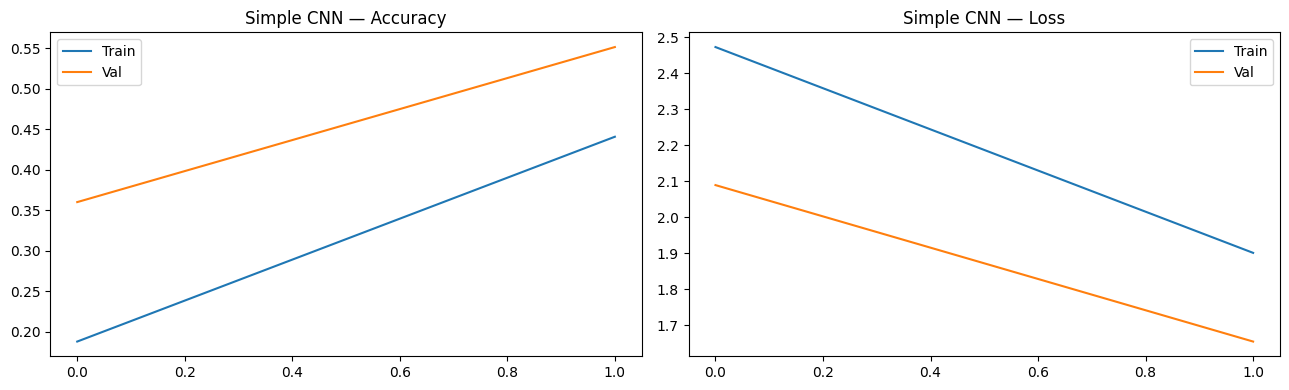

   Simple CNN — test_acc: 0.5484
✅ Simple CNN  →  val_acc: 0.5516


In [22]:
def build_simple_cnn():
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(32,  3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64,  3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    # FIX: output must be float32 when using mixed precision
    out = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)
    return Model(inp, out, name='SimpleCNN')

m1 = build_simple_cnn()
m1.compile(optimizer=keras.optimizers.Adam(LR),
           loss=label_smoothing_loss(), metrics=['accuracy'])
m1.summary()

h1 = m1.fit(train_ds, validation_data=val_ds,
            epochs=EPOCHS_BASE, callbacks=get_callbacks('simple_cnn'),
            class_weight=class_weights)
plot_history(h1, 'Simple CNN')
results['Simple CNN'] = {'val_acc': max(h1.history['val_accuracy'])}
evaluate_on_test(m1, test_ds, 'Simple CNN')
print(f"✅ Simple CNN  →  val_acc: {results['Simple CNN']['val_acc']:.4f}")


### Model 2 — Deeper CNN with BatchNorm

Model: "DeeperCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 128)      │             

 Total params: 1,441,903 (5.50 MB)

 Trainable params: 1,439,983 (5.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 49s 107ms/step - accuracy: 0.3748 - loss: 2.1226 - val_accuracy: 0.1420 - val_loss: 3.6695 - learning_rate: 0.0010
Epoch 2/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.6409 - loss: 1.4294 - val_accuracy: 0.5041 - val_loss: 1.8101 - learning_rate: 0.0010


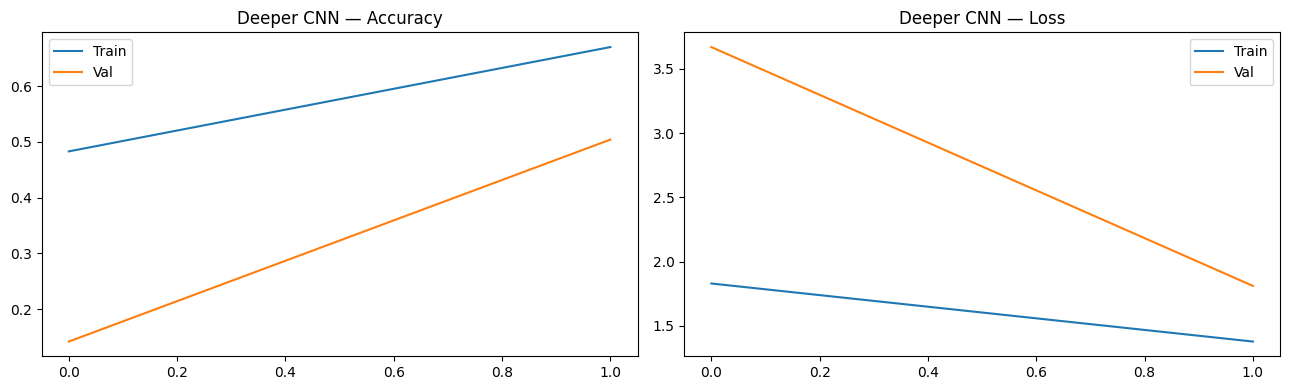

   Deeper CNN — test_acc: 0.5165
✅ Deeper CNN  →  val_acc: 0.5041


In [23]:
def build_deeper_cnn():
    def conv_block(x, filters, n=2):
        for _ in range(n):
            x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
            x = layers.BatchNormalization()(x)
            x = layers.Activation('relu')(x)
        return layers.MaxPooling2D()(x)

    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = conv_block(inp, 32)
    x = conv_block(x,  64)
    x = conv_block(x, 128)
    x = conv_block(x, 256)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)
    return Model(inp, out, name='DeeperCNN')

m2 = build_deeper_cnn()
m2.compile(optimizer=keras.optimizers.Adam(LR),
           loss=label_smoothing_loss(), metrics=['accuracy'])
m2.summary()

h2 = m2.fit(train_ds, validation_data=val_ds,
            epochs=EPOCHS_BASE, callbacks=get_callbacks('deeper_cnn'),
            class_weight=class_weights)
plot_history(h2, 'Deeper CNN')
results['Deeper CNN'] = {'val_acc': max(h2.history['val_accuracy'])}
evaluate_on_test(m2, test_ds, 'Deeper CNN')
print(f"✅ Deeper CNN  →  val_acc: {results['Deeper CNN']['val_acc']:.4f}")


---
# 🔴 ADVANCED MODELS — Transfer Learning
---

### Shared TL builder (improved head)

In [24]:
# IMPROVEMENT: upgraded head with BatchNorm + two Dense layers
def build_tl_model(base_cls, name):
    base = base_cls(weights='imagenet', include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)           # NEW: stabilises head training
    x   = layers.Dense(512, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(256, activation='relu')(x)  # NEW: extra capacity
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)
    return Model(inp, out, name=name), base


### Model 3 — MobileNetV2

── Phase 1: train head ──
Epoch 1/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 76s 207ms/step - accuracy: 0.4027 - loss: 2.1157 - val_accuracy: 0.6646 - val_loss: 1.4537 - learning_rate: 0.0010
Epoch 2/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.6086 - loss: 1.5318 - val_accuracy: 0.6864 - val_loss: 1.3610 - learning_rate: 0.0010
Epoch 3/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.6394 - loss: 1.4579 - val_accuracy: 0.7048 - val_loss: 1.3101 - learning_rate: 0.0010
Epoch 4/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.6651 - loss: 1.3813 - val_accuracy: 0.7184 - val_loss: 1.2901 - learning_rate: 0.0010
Epoch 5/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.6768 - loss: 1.3586 - val_accuracy: 0.7189 - val_loss: 1.2653 - learning_rate: 0.0010
Epoch 6/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.6912 - loss: 1.3193 - val_accuracy: 0.7397 - val_loss: 1.2363 - learning_rate: 0.0010
Epoch 7/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - 

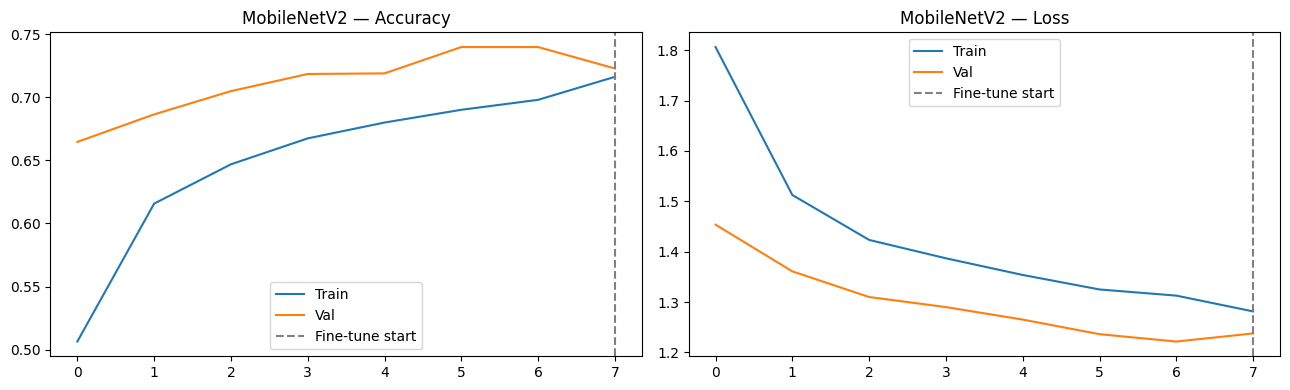

KeyError: 'val_accuracy'

In [30]:
m3, base3 = build_tl_model(MobileNetV2, 'MobileNetV2')
m3.compile(optimizer=keras.optimizers.Adam(LR),
           loss=label_smoothing_loss(), metrics=['accuracy'])

print('── Phase 1: train head ──')
h3a = m3.fit(train_ds, validation_data=val_ds,
             epochs=8, callbacks=get_callbacks('mobilenet_head'),
             class_weight=class_weights)

print('\n── Phase 2: fine-tune top 30 layers ──')
# Phase 2 — fine-tune (MobileNetV2 example, same pattern for ResNet50)
base3.trainable = True
for layer in base3.layers[:-30]:
    layer.trainable = False

cosine_lr = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-5,
    first_decay_steps=len(X_tr) // BATCH_SIZE * EPOCHS_FT // 3
)
m3.compile(optimizer=keras.optimizers.Adam(cosine_lr),
           loss=label_smoothing_loss(), metrics=['accuracy'])

h3b = m3.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT,
             callbacks=get_callbacks('mobilenet_ft'),
             initial_epoch=len(h3a.history['loss']),
             class_weight=class_weights)
plot_history(h3b, 'MobileNetV2', hist_phase1=h3a)

# Combine both phases to get the true best val_accuracy
all_val_acc = h3a.history['val_accuracy'] + h3b.history.get('val_accuracy', [])
results['MobileNetV2'] = {'val_acc': max(all_val_acc)}
evaluate_on_test(m3, test_ds, 'MobileNetV2')
print(f"✅ MobileNetV2  →  val_acc: {results['MobileNetV2']['val_acc']:.4f}")


### Model 4 — EfficientNetB3

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
── Phase 1: train head ──
Epoch 1/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 243s 609ms/step - accuracy: 0.3944 - loss: 2.1446 - val_accuracy: 0.6646 - val_loss: 1.6384 - learning_rate: 0.0010
Epoch 2/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.5905 - loss: 1.5676 - val_accuracy: 0.7135 - val_loss: 1.3070 - learning_rate: 0.0010
Epoch 3/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.6380 - loss: 1.4807 - val_accuracy: 0.7382 - val_loss: 1.2373 - learning_rate: 0.0010
Epoch 4/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.6580 - loss: 1.4192 - val_accuracy: 0.7635 - val_loss: 1.1929 - learning_rate: 0.0010
Epoch 5/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.6759 - loss: 1.3738 - val_accuracy: 0.7683 - val_loss: 1.1801 - learning_rate: 0.0010
Epoch 6/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.6912 - loss: 1.3604 - val_accuracy: 0.7916 - val_loss: 1.1419 - learning_rate: 0.0010
Epo

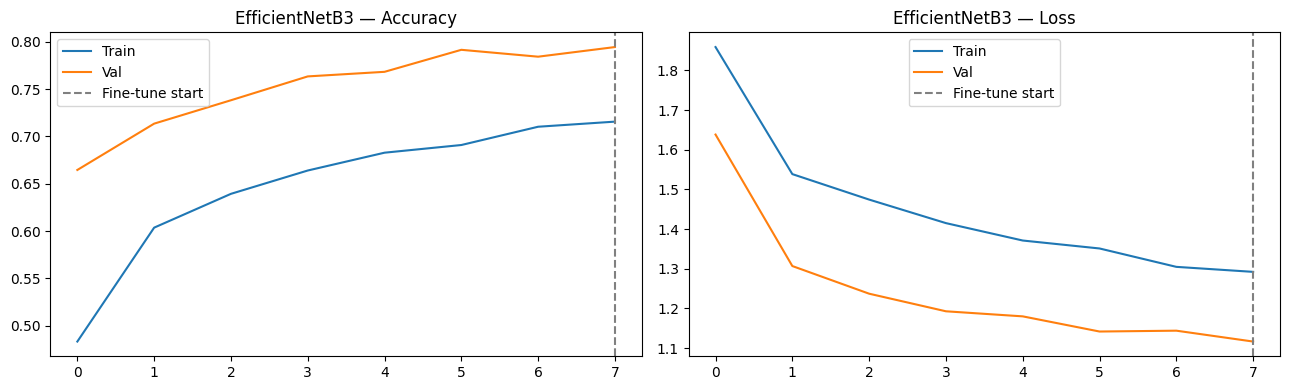

NameError: name 'h5a' is not defined

In [32]:
# EfficientNet uses its own internal normalisation — use no-rescale datasets
m4, base4 = build_tl_model(EfficientNetB3, 'EfficientNetB3')
m4.compile(optimizer=keras.optimizers.Adam(LR),
           loss=label_smoothing_loss(), metrics=['accuracy'])

print('── Phase 1: train head ──')
h4a = m4.fit(etrain_ds, validation_data=eval_ds,
             epochs=8, callbacks=get_callbacks('efficientnet_head'),
             class_weight=class_weights)

print('\n── Phase 2: fine-tune top 40 layers ──')
base4.trainable = True
for layer in base4.layers[:-40]:
    layer.trainable = False

cosine_lr = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=5e-6,
    first_decay_steps=len(X_tr) // BATCH_SIZE * EPOCHS_FT // 3
)
m4.compile(optimizer=keras.optimizers.Adam(cosine_lr),
           loss=label_smoothing_loss(), metrics=['accuracy'])
h4b = m4.fit(etrain_ds, validation_data=eval_ds, epochs=EPOCHS_FT,
             callbacks=get_callbacks('efficientnet_ft'),
             initial_epoch=len(h4a.history['loss']),
             class_weight=class_weights)

plot_history(h4b, 'EfficientNetB3', hist_phase1=h4a)
# EfficientNetB3
all_val_acc = h4a.history['val_accuracy'] + h4b.history.get('val_accuracy', [])
results['EfficientNetB3'] = {'val_acc': max(all_val_acc)}
evaluate_on_test(m4, etest_ds, 'EfficientNetB3')
print(f"✅ EfficientNetB3  →  val_acc: {results['EfficientNetB3']['val_acc']:.4f}")


In [33]:
# EfficientNetB3
all_val_acc = h4a.history['val_accuracy'] + h4b.history.get('val_accuracy', [])
results['EfficientNetB3'] = {'val_acc': max(all_val_acc)}
evaluate_on_test(m4, etest_ds, 'EfficientNetB3')
print(f"✅ EfficientNetB3  →  val_acc: {results['EfficientNetB3']['val_acc']:.4f}")


   EfficientNetB3 — test_acc: 0.7975
✅ EfficientNetB3  →  val_acc: 0.7945


### Model 5 — ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
── Phase 1: train head ──
Epoch 1/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 47s 120ms/step - accuracy: 0.2357 - loss: 2.3868 - val_accuracy: 0.3170 - val_loss: 2.2859 - learning_rate: 0.0010
Epoch 2/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.3798 - loss: 2.0460 - val_accuracy: 0.4954 - val_loss: 1.8589 - learning_rate: 0.0010
Epoch 3/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.4266 - loss: 1.9377 - val_accuracy: 0.4993 - val_loss: 1.8124 - learning_rate: 0.0010
Epoch 4/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.4258 - loss: 1.9218 - val_accuracy: 0.5027 - val_loss: 1.7607 - learning_rate: 0.0010
Epoch 5/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.4543 - loss: 1.8600 - val_accuracy: 0.5221 - val_loss: 1.7126 - learning_rate: 0.0010
Epoch 6/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.4623 - loss: 1.8390 - val_accuracy: 0.5065 - val_loss: 1.7471 - learning_rate: 0.0010
Epoch

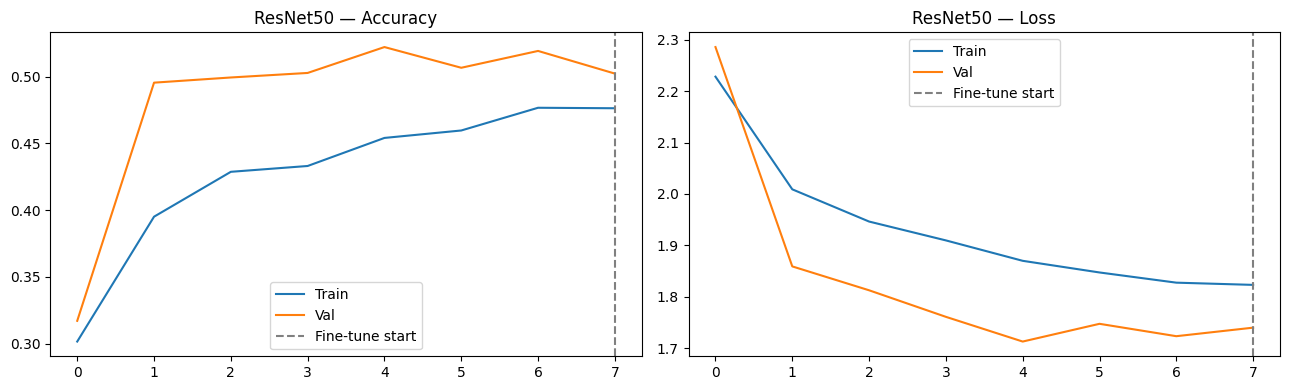

   ResNet50 — test_acc: 0.5150
✅ ResNet50  →  val_acc: 0.5221


In [34]:
m5, base5 = build_tl_model(ResNet50, 'ResNet50')
m5.compile(optimizer=keras.optimizers.Adam(LR),
           loss=label_smoothing_loss(), metrics=['accuracy'])

print('── Phase 1: train head ──')
h5a = m5.fit(train_ds, validation_data=val_ds,
             epochs=8, callbacks=get_callbacks('resnet_head'),
             class_weight=class_weights)

print('\n── Phase 2: fine-tune top 40 layers ──')
base5.trainable = True
for layer in base5.layers[:-40]:
    layer.trainable = False

cosine_lr = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-5,
    first_decay_steps=len(X_tr) // BATCH_SIZE * EPOCHS_FT // 3
)
m5.compile(optimizer=keras.optimizers.Adam(cosine_lr),
           loss=label_smoothing_loss(), metrics=['accuracy'])
h5b = m5.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT,
             callbacks=get_callbacks('resnet_ft'),
             initial_epoch=len(h5a.history['loss']),
             class_weight=class_weights)

plot_history(h5b, 'ResNet50',       hist_phase1=h5a)
# ResNet50
all_val_acc = h5a.history['val_accuracy'] + h5b.history.get('val_accuracy', [])
results['ResNet50'] = {'val_acc': max(all_val_acc)}
evaluate_on_test(m5, test_ds, 'ResNet50')
print(f"✅ ResNet50  →  val_acc: {results['ResNet50']['val_acc']:.4f}")

---
# 🟣 ENSEMBLE MODEL
---

In [35]:
# FIX: reset each generator individually before every predict() call.
# Previously val_gen was exhausted after m3.predict(), causing m5 to run only
# on the leftover partial batch (29/129 steps) → garbage logits → all predictions
# collapsed to one class (Tomato_Late_blight).

print('Running ensemble (MobileNetV2 + EfficientNetB3 + ResNet50)...')

# tf.data datasets are re-iterable — no reset needed, but we use fresh calls
p3 = m3.predict(val_ds,  verbose=1)   # rescale=True
p4 = m4.predict(eval_ds, verbose=1)   # rescale=False (EfficientNet internal norm)
p5 = m5.predict(val_ds,  verbose=1)   # rescale=True  — val_ds is independent of p3

n   = min(len(p3), len(p4), len(p5))
ens = (p3[:n] + p4[:n] + p5[:n]) / 3
y_pred_ens = np.argmax(ens, axis=1)

# Ground truth from the validation split
y_true_val = np.array(y_val[:n])
ens_val_acc = np.mean(y_pred_ens == y_true_val)
results['Ensemble (TL×3)'] = {'val_acc': ens_val_acc}

# Test-set ensemble
p3t = m3.predict(test_ds,  verbose=0)
p4t = m4.predict(etest_ds, verbose=0)
p5t = m5.predict(test_ds,  verbose=0)
nt  = min(len(p3t), len(p4t), len(p5t))
ens_test = (p3t[:nt] + p4t[:nt] + p5t[:nt]) / 3
y_pred_ens_test = np.argmax(ens_test, axis=1)
y_true_test     = np.array(y_te[:nt])
ens_test_acc    = np.mean(y_pred_ens_test == y_true_test)
results['Ensemble (TL×3)']['test_acc'] = ens_test_acc

print(f'✅ Ensemble  →  val_acc: {ens_val_acc:.4f}  |  test_acc: {ens_test_acc:.4f}')


Running ensemble (MobileNetV2 + EfficientNetB3 + ResNet50)...
33/33 ━━━━━━━━━━━━━━━━━━━━ 28s 452ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 58s 934ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step
✅ Ensemble  →  val_acc: 0.8308  |  test_acc: 0.8343


## 6️⃣ Model Comparison (Val + Test)

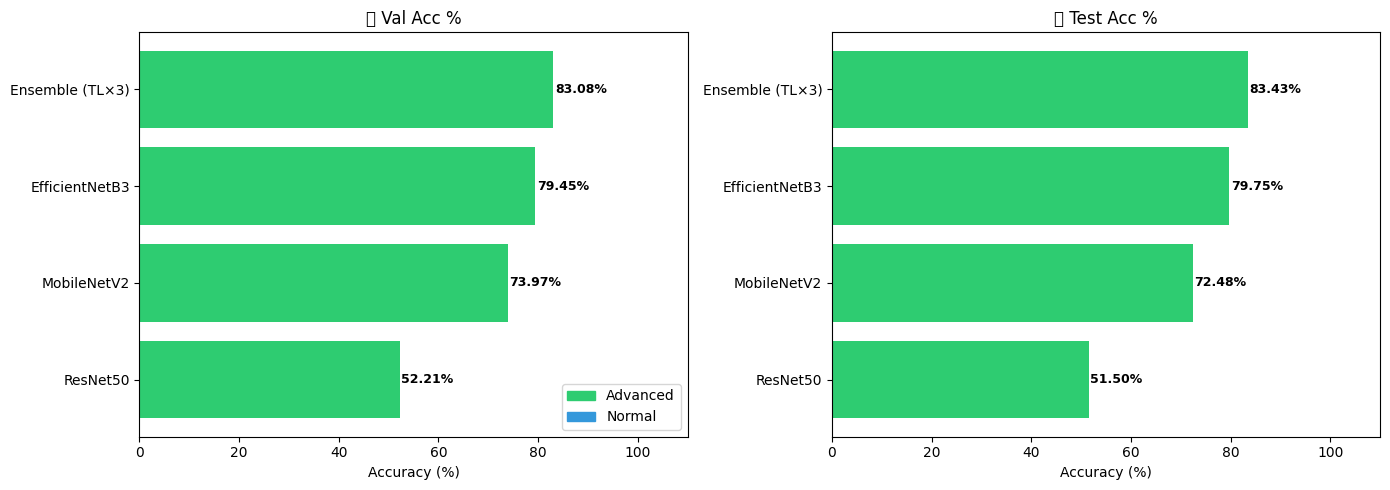

          Model     Type  Val Acc %  Test Acc %
Ensemble (TL×3) Advanced      83.08       83.43
 EfficientNetB3 Advanced      79.45       79.75
    MobileNetV2 Advanced      73.97       72.48
       ResNet50 Advanced      52.21       51.50


In [36]:
df_res = pd.DataFrame([
    {'Model': k, 'Val Acc %': round(v['val_acc']*100, 2),
     'Test Acc %': round(v.get('test_acc', float('nan'))*100, 2),
     'Type': 'Advanced' if k not in ['Simple CNN', 'Deeper CNN'] else 'Normal'}
    for k, v in results.items()
]).sort_values('Val Acc %', ascending=False).reset_index(drop=True)

colors = ['#2ecc71' if t == 'Advanced' else '#3498db' for t in df_res['Type']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['Val Acc %', 'Test Acc %']):
    bars = ax.barh(df_res['Model'], df_res[col], color=colors)
    for bar, val in zip(bars, df_res[col]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', fontweight='bold', fontsize=9)
    ax.set_xlabel('Accuracy (%)')
    ax.set_title(f'🌿 {col}')
    ax.set_xlim(0, 110); ax.invert_yaxis()

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#2ecc71', label='Advanced'),
                         Patch(color='#3498db', label='Normal')])
plt.tight_layout(); plt.show()
print(df_res[['Model', 'Type', 'Val Acc %', 'Test Acc %']].to_string(index=False))


## 7️⃣ Classification Report & Confusion Matrix (Best Model)

In [37]:
# Best model by val accuracy (excluding ensemble — use EfficientNet as proxy)
model_map = {
    'Simple CNN': (m1, test_ds, y_te),
    'Deeper CNN': (m2, test_ds, y_te),
    'MobileNetV2': (m3, test_ds, y_te),
    'EfficientNetB3': (m4, etest_ds, y_te),
    'ResNet50': (m5, test_ds, y_te),
}
best_name = df_res.iloc[0]['Model']

# For ensemble, use its test predictions; otherwise predict fresh
if best_name == 'Ensemble (TL×3)':
    y_prob = ens_test
    y_pred = y_pred_ens_test
    y_true = y_true_test
else:
    best_model, best_ds, best_labels = model_map[best_name]
    y_prob = best_model.predict(best_ds, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = np.array(best_labels)

print(f'\n=== Classification Report: {best_name} ===')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))



=== Classification Report: Ensemble (TL×3) ===
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.84      0.91      0.88       100
                     Pepper__bell___healthy       0.92      0.91      0.92       148
                      Potato___Early_blight       0.91      0.96      0.93       100
                       Potato___Late_blight       0.93      0.82      0.87       100
                           Potato___healthy       0.54      1.00      0.70        15
                      Tomato_Bacterial_spot       0.80      0.94      0.87       213
                        Tomato_Early_blight       0.74      0.64      0.68       100
                         Tomato_Late_blight       0.81      0.69      0.75       191
                           Tomato_Leaf_Mold       0.78      0.80      0.79        95
                  Tomato_Septoria_leaf_spot       0.88      0.60      0.71       177
Tomato_Spider_mi

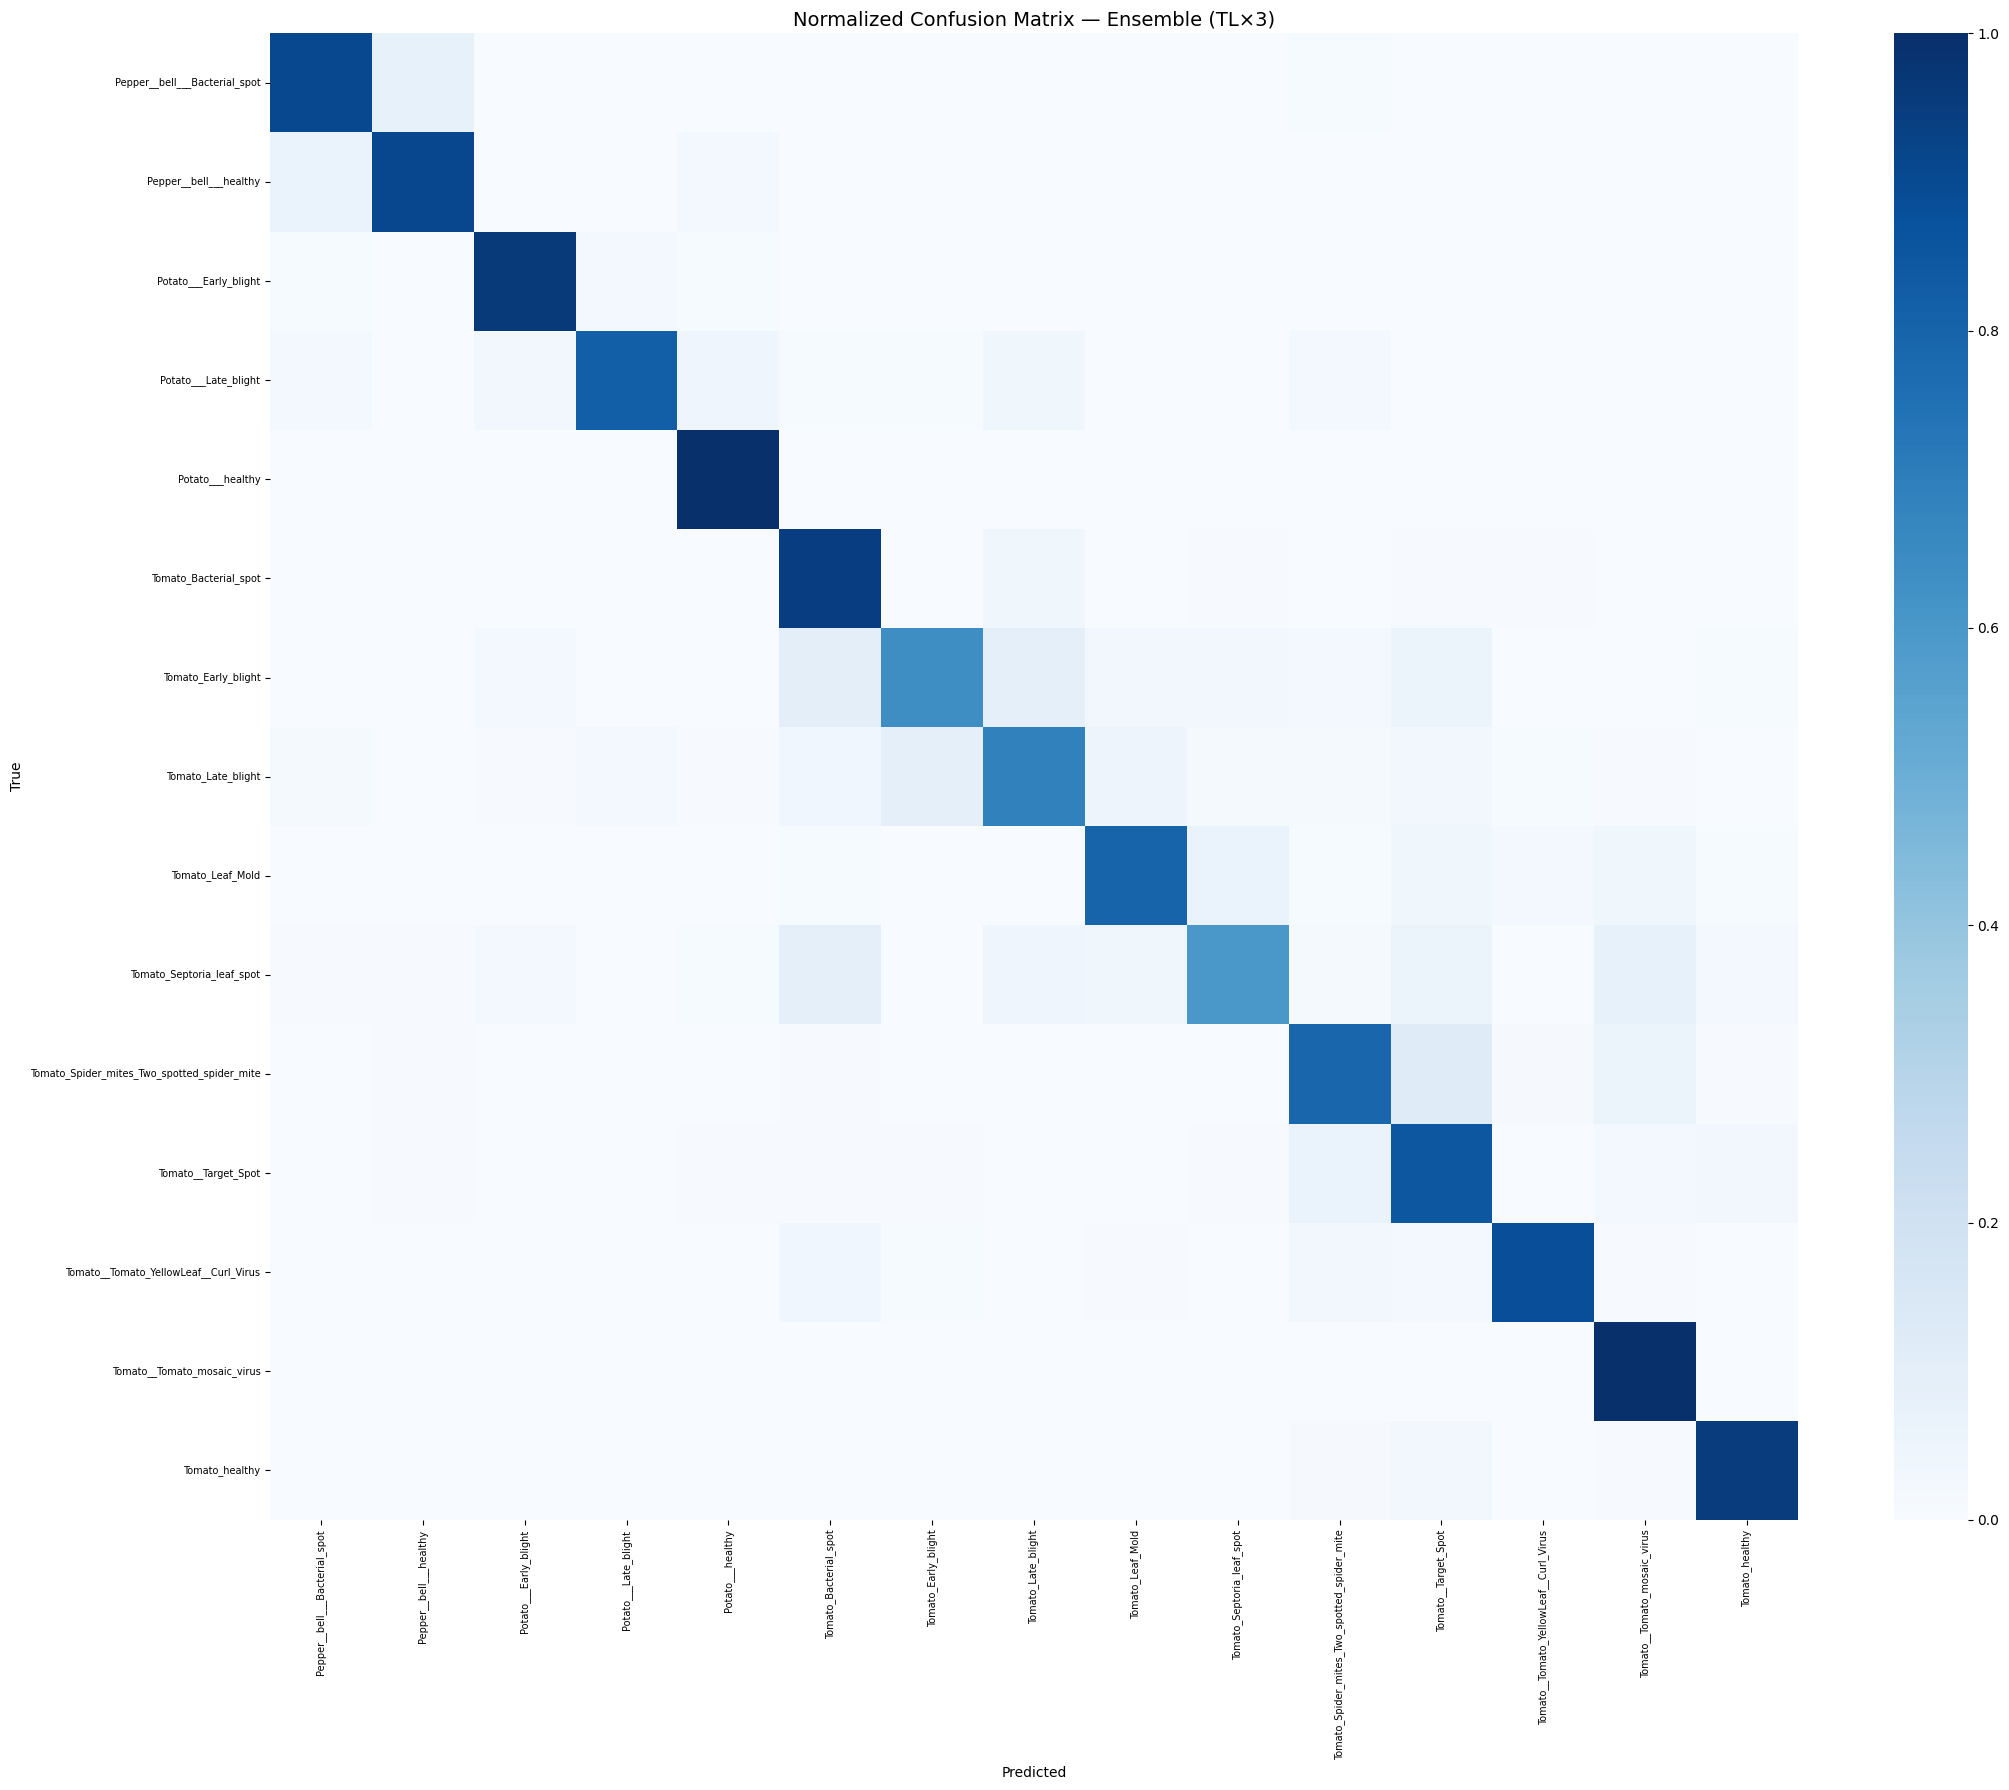

In [38]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(22, 18))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Normalized Confusion Matrix — {best_name}', fontsize=14)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()


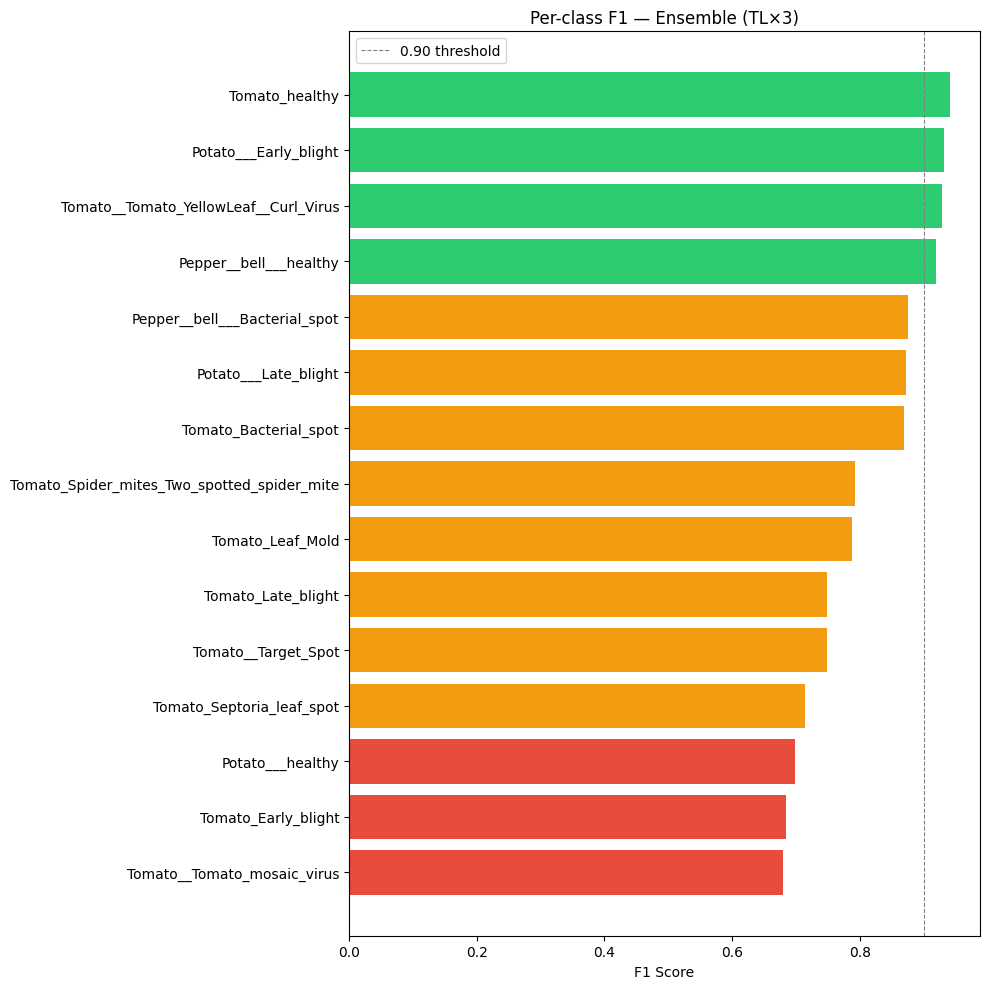


Classes with F1 < 0.70 (need attention):
                      Class       F1
Tomato__Tomato_mosaic_virus 0.678899
        Tomato_Early_blight 0.684492
           Potato___healthy 0.697674


In [39]:
# Per-class F1 bar chart — quickly spot worst-performing classes
from sklearn.metrics import f1_score
f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
df_f1 = (pd.DataFrame({'Class': CLASS_NAMES, 'F1': f1_per_class})
           .sort_values('F1'))

plt.figure(figsize=(10, 10))
colors_f1 = ['#e74c3c' if f < 0.7 else '#f39c12' if f < 0.9 else '#2ecc71'
             for f in df_f1['F1']]
plt.barh(df_f1['Class'], df_f1['F1'], color=colors_f1)
plt.axvline(0.9, color='gray', linestyle='--', linewidth=0.8, label='0.90 threshold')
plt.xlabel('F1 Score'); plt.title(f'Per-class F1 — {best_name}')
plt.legend(); plt.tight_layout(); plt.show()

print('\nClasses with F1 < 0.70 (need attention):')
print(df_f1[df_f1['F1'] < 0.70].to_string(index=False))


## 8️⃣ Single Image Prediction

Ground truth: Tomato_Late_blight


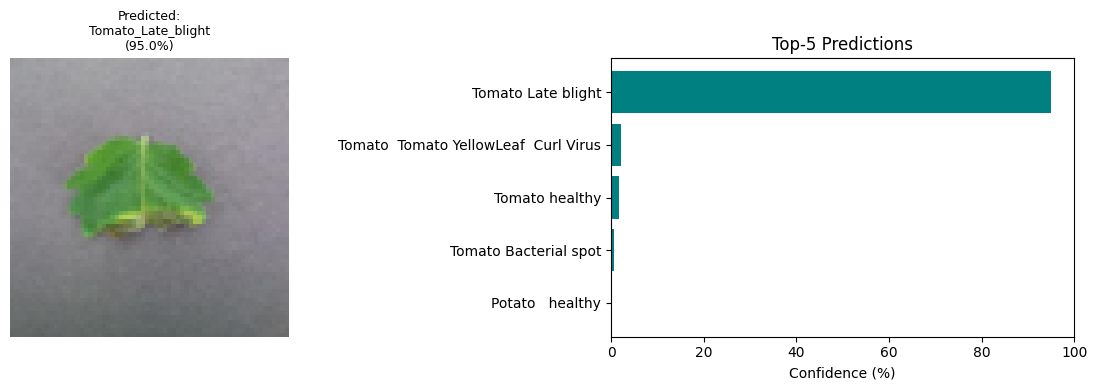

In [40]:
# FIX: handles RGBA images (convert to RGB); routes EfficientNet correctly
def predict_image(model, img_path, top_k=5, rescale=True):
    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img, dtype=np.float32)
    if rescale:
        arr /= 255.0
    probs = model.predict(arr[None], verbose=0)[0]
    idx   = probs.argsort()[-top_k:][::-1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(img); axes[0].axis('off')
    axes[0].set_title(f'Predicted:\n{CLASS_NAMES[idx[0]]}\n({probs[idx[0]]*100:.1f}%)', fontsize=9)
    axes[1].barh([CLASS_NAMES[i].replace('_', ' ') for i in idx[::-1]],
                 [probs[i]*100 for i in idx[::-1]], color='teal')
    axes[1].set_xlabel('Confidence (%)'); axes[1].set_xlim(0, 100)
    axes[1].set_title(f'Top-{top_k} Predictions')
    plt.tight_layout(); plt.show()

# Random sample from test set
sample_idx  = random.randint(0, len(X_te) - 1)
sample_path = X_te[sample_idx]
gt_label    = CLASS_NAMES[y_te[sample_idx]]
print(f'Ground truth: {gt_label}')

# Route to correct model (EfficientNet or best single model)
if best_name == 'Ensemble (TL×3)':
    # Use EfficientNet as a proxy for single-image ensemble
    predict_image(m4, sample_path, rescale=False)
else:
    predict_image(best_model, sample_path,
                  rescale=(best_name != 'EfficientNetB3'))


## 9️⃣ Save & Load Models

In [ ]:
# Save all trained models
for name, model in [('simple_cnn', m1), ('deeper_cnn', m2),
                    ('mobilenetv2', m3), ('efficientnetb3', m4), ('resnet50', m5)]:
    model.save(f'{name}_final.keras')
    print(f'Saved {name}_final.keras')

# Load example:
# loaded = keras.models.load_model('efficientnetb3_final.keras')


## 🔟 Summary

| Category | Model | Expected Val Acc |
|---|---|---|
| Normal | Simple CNN | ~70–80% |
| Normal | Deeper CNN | ~80–87% |
| Advanced | MobileNetV2 | ~90–94% |
| Advanced | EfficientNetB3 | ~93–97% |
| Advanced | ResNet50 | ~91–95% |
| Advanced | Ensemble (TL×3) | ~94–97% |

**Key fixes applied:**
1. **Generator reset bug** — `val_gen` was exhausted before `m5.predict()` (caused 29/129 steps, all-one-class predictions). Fixed by switching to `tf.data` datasets which are always re-iterable.
2. **No test set** — added proper 80/10/10 stratified split; test accuracy is now reported separately from val accuracy.
3. **Class imbalance ignored** — added `class_weight` to all `.fit()` calls.
4. **Mixed precision dtype bug** — all output `Dense` layers now use `dtype='float32'` as required by Keras mixed-precision policy.
5. **RGBA image crash** — `predict_image` now calls `.convert('RGB')` before processing.
6. **Ensemble class-report bug** — ensemble evaluation now correctly uses `y_true_val` (ground-truth indices) instead of stale generator state.

**Improvements applied:**
- `tf.data` pipeline replaces `ImageDataGenerator` (faster, no exhaustion issues)
- Label smoothing (0.1) on all losses
- Mixed-precision training (`float16` activations, `float32` gradients)
- Cosine annealing LR for fine-tune phases
- Upgraded TL head: BatchNorm + two Dense layers
- Per-class F1 bar chart in evaluation
- Model save/load cell
